<a href="https://colab.research.google.com/github/JuCaRiCo/202602-AnaliticaDescriptivaPredictiva/blob/main/Sesion15_02_Datos_Ausentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Datos ausentes: detección, mecanismos y tratamiento exploratorio
**Programación para Analítica Descriptiva y Predictiva** · MIAAD · UACJ

Unidad 2 · Sesión síncrona · Parte 2 de 2 · **Notebook de apoyo para la sesión**

Sigue la sesión ejecutando cada celda. En las celdas **Predicción**, anota qué esperas antes de ejecutar. En las celdas **Tu observación**, escribe lo que observas. La versión completa, con todas las explicaciones, se publica después de la sesión.

| Bloque | Contenido |
|---|---|
| 0 | Preparación del entorno |
| 1 | ¿Sobre cuántos datos se calculó? ¿Qué es un dato perdido? |
| 2 | Detección y cuantificación |
| 3 | Visualización con `missingno` |
| 4 | Mecanismos: MCAR, MAR y MNAR |
| 5 | Efecto en las medidas descriptivas |
| 6 | Tratamiento exploratorio |
| 7 | Cuando el faltante tiene significado |
| 8 | Cierre |

---
## Bloque 0. Preparación del entorno

In [1]:
!pip install missingno -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
ruta_air = '/content/drive/MyDrive/MIAAD/202602-AnaliticaDescriptivaPredictiva/DataFiles/Airdata.csv'
df_air = pd.read_csv(ruta_air)
df_air['DateTime'] = pd.to_datetime(df_air['DateTime'], format='%m/%d/%Y %H:%M')

url_bnb = 'https://raw.githubusercontent.com/ManarOmar/New-York-Airbnb-2019/master/AB_NYC_2019.csv'
df_bnb = pd.read_csv(url_bnb)

df_air.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DateTime        8784 non-null   datetime64[ns]
 1   Temperature     8784 non-null   float64       
 2   Humidity        8784 non-null   int64         
 3   Wind_Speed      8784 non-null   float64       
 4   Wind_Direction  8784 non-null   float64       
 5   NO2_Location_A  8664 non-null   float64       
 6   NO2_Location_B  8204 non-null   float64       
 7   NO2_Location_C  8652 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 549.1 KB


---
## Bloque 1. ¿Sobre cuántos datos se calculó?

**Predicción.** ¿Sobre cuántas horas se calculará la mediana de NO₂ en la estación B? El año 2020 tuvo 366 días.

In [5]:
no2_b = df_air['NO2_Location_B']

print('Mediana:', no2_b.median())
print('IQR:    ', no2_b.quantile(0.75) - no2_b.quantile(0.25))
print('Horas del año:             ', len(no2_b))
print('Horas usadas en el cálculo:', no2_b.count())

Mediana: 22.75
IQR:     24.707500000000003
Horas del año:              8784
Horas usadas en el cálculo: 8204


**Tu observación:** _escribe aquí lo que observas._

### 1.2 ¿Qué es un dato perdido?

Una celda vacía **que esperábamos tener**. No lo son:

| Tipo | Ejemplo |
|---|---|
| Datos censurados | Supervivencia de un paciente al cierre del estudio |
| Estructuralmente ausentes | Modelo de automóvil de quien no tiene automóvil |

**Tu observación:** _¿qué causas de datos perdidos conoces en tu propio dataset?_

---
## Bloque 2. Detección y cuantificación

`df.isna()` → `True` donde falta. `.sum()` cuenta; `.mean()` da la proporción.

**Predicción.** ¿Qué columnas tendrán faltantes? ¿Cuál tendrá más?

### Forma 1: `df.info()` → columna `Non-Null Count`

### Forma 2: `df.isna()` en un ejemplo pequeño

In [7]:
df_small = pd.DataFrame({
    'A': [1, np.nan, 3],
    'B': [4, 5, None],
    'C': ['Rojo', 'Verde', None]
})
print(df_small)
print()
print(df_small.isna())

     A    B      C
0  1.0  4.0   Rojo
1  NaN  5.0  Verde
2  3.0  NaN   None

       A      B      C
0  False  False  False
1   True  False  False
2  False   True   True


Con muchas filas, se resume con `.sum()` y `.mean()`.

In [8]:
faltantes = pd.DataFrame({
    'faltantes': df_air.isna().sum(),
    'porcentaje': (df_air.isna().mean() * 100).round(2)
})
faltantes

,faltantes,porcentaje
DateTime,0,0.00
Temperature,0,0.00
Humidity,0,0.00
Wind_Speed,0,0.00
Wind_Direction,0,0.00
NO2_Location_A,120,1.37
NO2_Location_B,580,6.60
NO2_Location_C,132,1.50


**Tu observación:** _escribe aquí lo que observas._

### Forma 3: gráfico de barras del porcentaje de faltantes

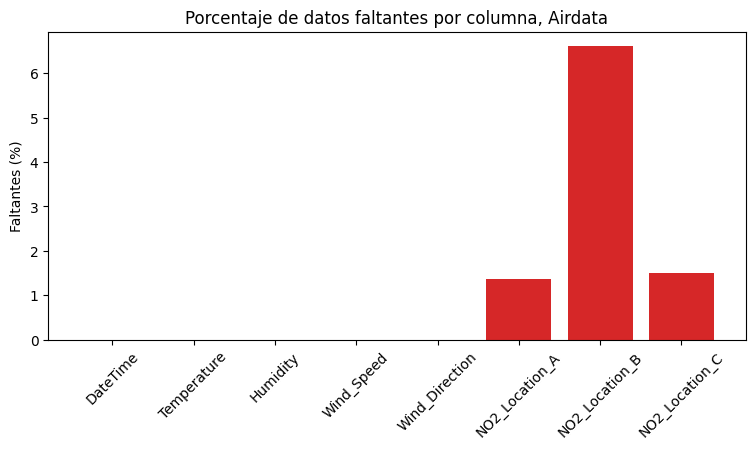

In [9]:
pct = df_air.isna().mean() * 100

plt.figure(figsize=(9, 4))
plt.bar(pct.index, pct.values, color='tab:red')
plt.title('Porcentaje de datos faltantes por columna, Airdata')
plt.ylabel('Faltantes (%)')
plt.xticks(rotation=45)
plt.show()

### Práctica

Carga el archivo **health_nutrition.csv** (disponible en Teams; guárdalo en `MyDrive/Unidad02/`) en un DataFrame llamado `df_salud`:

```python
df_salud = pd.read_csv('/content/drive/MyDrive/Unidad02/health_nutrition.csv')
```

El archivo tiene 14,300 personas y 50 columnas de datos demográficos y medidas corporales. Los nombres de las columnas siguen la nomenclatura de la encuesta NHANES del CDC de Estados Unidos (por ejemplo, `RIDAGEYR` es la edad en años, `RIAGENDR` el sexo, `BMXWT` el peso y `BMXBMI` el índice de masa corporal).

1. Usa `info()`, `isna().sum()` e `isna().mean()` para obtener la cantidad y el porcentaje de valores perdidos por columna.
2. Ordena los porcentajes de mayor a menor (`.sort_values(ascending=False)`) y grafícalos con `plt.bar`.
3. ¿Cuántas columnas están completas? ¿Cuántas tienen más de 50% de faltantes? ¿Hay alguna completamente vacía?

### Faltantes por fila: `axis=1`

In [10]:
faltantes_por_fila = df_air.isna().sum(axis=1)
print(faltantes_por_fila.value_counts().sort_index())

filas_incompletas = df_air.isna().any(axis=1).sum()
print()
print('Filas con al menos un faltante:', filas_incompletas)
print('Porcentaje:', round(filas_incompletas / len(df_air) * 100, 2), '%')

0    7970
1     797
2      16
3       1
Name: count, dtype: int64

Filas con al menos un faltante: 814
Porcentaje: 9.27 %


**Tu observación:** _escribe aquí lo que observas._

### Error intencional 1: convertir a entero una columna con faltantes

Supón que quieres redondear las concentraciones de la estación A a números enteros.

In [11]:
df_air['NO2_Location_A'].astype(int)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

**¿Qué dice el error y cómo lo corriges?** _escribe aquí._

In [12]:
df_air['NO2_Location_A'].round().astype('Int64').head()

,NO2_Location_A
0,39
1,38
2,<NA>
3,37
4,30


### Un error silencioso: comparar con `np.nan`

**Predicción.** ¿Cuántas filas devolverá la siguiente comparación?

In [18]:
(df_air['NO2_Location_A'] == np.nan).sum()

np.int64(0)

**Tu observación:** _escribe aquí lo que observas._

In [19]:
df_air['NO2_Location_A'].isna().sum()

np.int64(120)

---
## Bloque 3. Visualización con `missingno`

`msno.matrix(df)`: gris = presente, blanco = faltante; las filas conservan su orden.

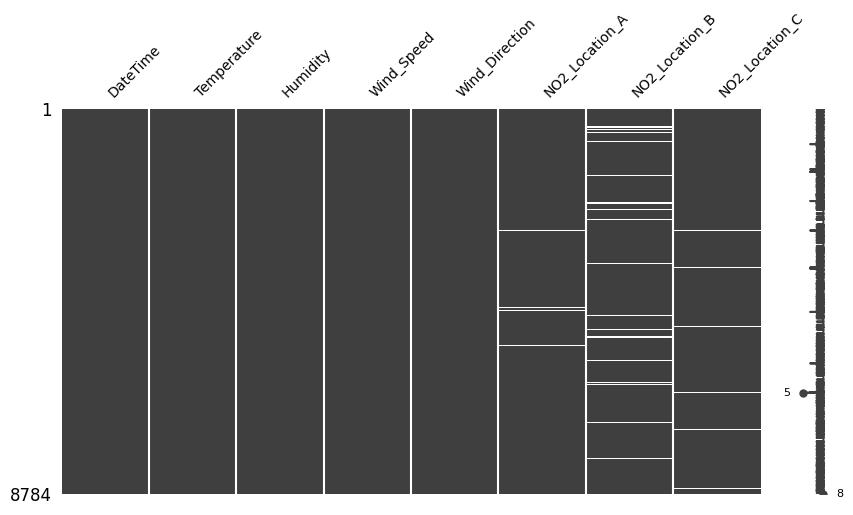

In [17]:
msno.matrix(df_air, figsize=(10, 5), fontsize=10)
plt.show()

**Predicción.** ¿Qué columna tiene faltantes dispersos y cuál en bloques? Veamos solo junio.

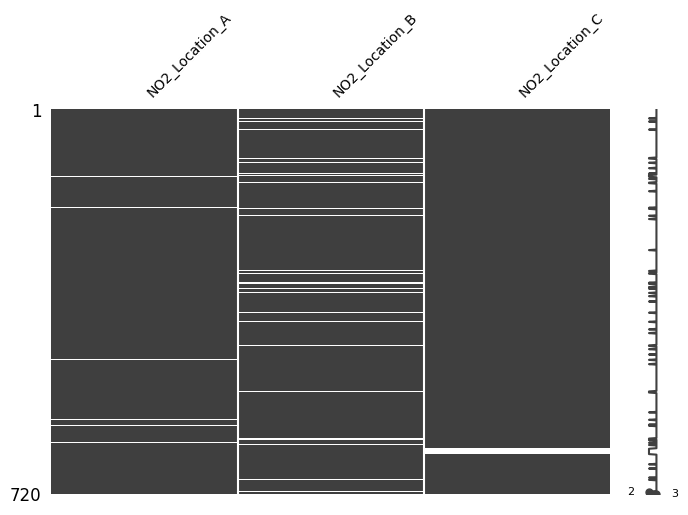

In [20]:
junio = df_air[df_air['DateTime'].dt.month == 6]
msno.matrix(junio[['NO2_Location_A', 'NO2_Location_B', 'NO2_Location_C']], figsize=(8, 5), fontsize=10)
plt.show()

**Tu observación:** _escribe aquí lo que observas._

### Error intencional 2: `missingno` con una sola columna

In [21]:
msno.matrix(df_air['NO2_Location_C'])

IndexError: tuple index out of range

**¿Qué dice el error y cómo lo corriges?** _escribe aquí._

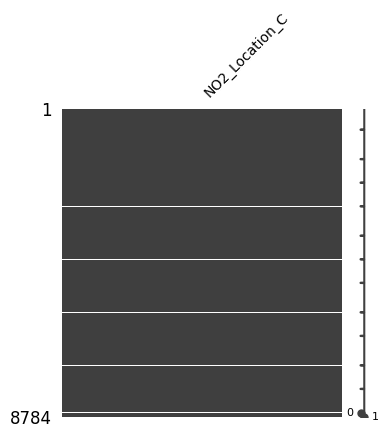

In [22]:
msno.matrix(df_air[['NO2_Location_C']], figsize=(4, 4), fontsize=10)
plt.show()

`msno.bar(df)`: valores presentes por columna.

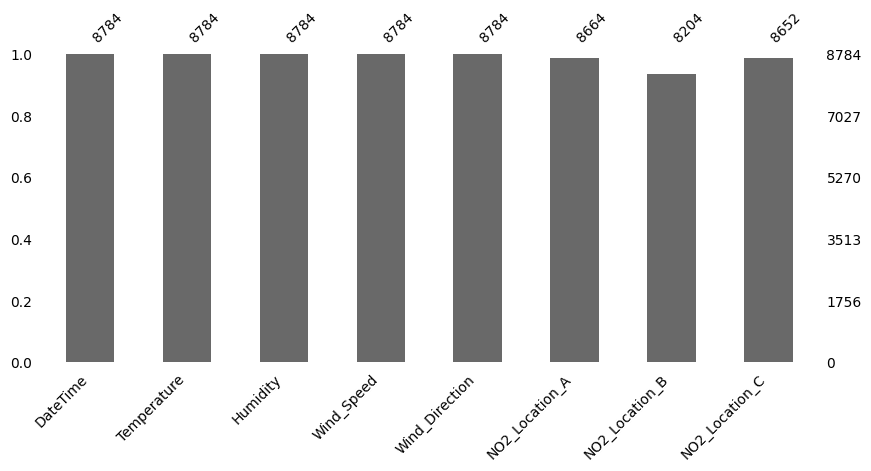

In [23]:
msno.bar(df_air, figsize=(10, 4), fontsize=10)
plt.show()

`msno.heatmap(df)`: ¿faltan juntas dos columnas? (1 = siempre juntas, 0 = sin relación)

**Predicción.** ¿Qué valores esperas?

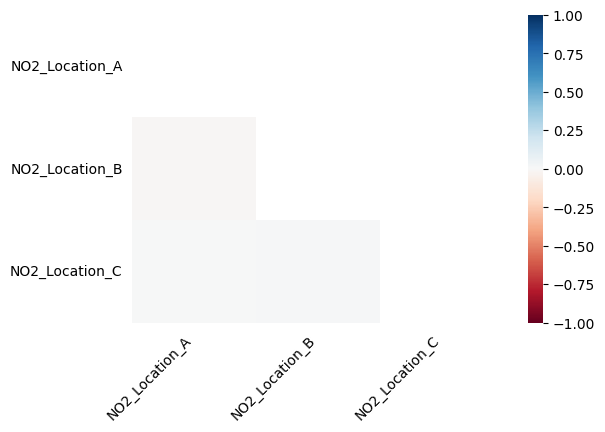

In [24]:
msno.heatmap(df_air, figsize=(6, 4), fontsize=10)
plt.show()

**Tu observación:** _escribe aquí lo que observas._

### Práctica

Aplica `msno.matrix`, `msno.bar` y `msno.heatmap` a `df_salud`. Con 50 columnas, conviene usar `figsize=(14, 6)` y `fontsize=8`.

- ¿Qué grupos de columnas pierden datos **juntas**? Observa las columnas que empiezan con `BMX` (medidas) y con `BMI` (comentarios sobre esas medidas).
- Busca evidencia de datos **no aplicables**: compara la edad (`RIDAGEYR`) de las personas con y sin `DMDEDUC2` (nivel educativo), y el sexo (`RIAGENDR`) y la edad de quienes tienen `RIDEXPRG` (embarazo al momento del examen). ¿Son datos perdidos o preguntas que no correspondían?

---
## Bloque 4. Mecanismos: MCAR, MAR y MNAR

| Mecanismo | La ausencia depende de... |
|---|---|
| **MCAR** | Nada: es completamente al azar |
| **MAR** | Otra variable **observada** |
| **MNAR** | El **propio valor** faltante |

**Estrategia:** comparar otras variables con y sin faltante.

### 4.1 Estación A

In [25]:
falta_a = df_air['NO2_Location_A'].isna()

print('Viento cuando A falta:     ', round(df_air.loc[falta_a, 'Wind_Speed'].mean(), 2))
print('Viento cuando A está:      ', round(df_air.loc[~falta_a, 'Wind_Speed'].mean(), 2))
print('Temperatura cuando A falta:', round(df_air.loc[falta_a, 'Temperature'].mean(), 2))
print('Temperatura cuando A está: ', round(df_air.loc[~falta_a, 'Temperature'].mean(), 2))

Viento cuando A falta:      11.1
Viento cuando A está:       11.28
Temperatura cuando A falta: 13.15
Temperatura cuando A está:  13.11


**Tu observación:** _escribe aquí lo que observas._

### 4.2 Estación B

**Predicción.** ¿Qué esperas al hacer la misma comparación en la estación B?

In [26]:
falta_b = df_air['NO2_Location_B'].isna()

print('Viento cuando B falta:     ', round(df_air.loc[falta_b, 'Wind_Speed'].mean(), 2))
print('Viento cuando B está:      ', round(df_air.loc[~falta_b, 'Wind_Speed'].mean(), 2))
print('Temperatura cuando B falta:', round(df_air.loc[falta_b, 'Temperature'].mean(), 2))
print('Temperatura cuando B está: ', round(df_air.loc[~falta_b, 'Temperature'].mean(), 2))

Viento cuando B falta:      17.85
Viento cuando B está:       10.81
Temperatura cuando B falta: 12.01
Temperatura cuando B está:  13.19


Comparemos las distribuciones completas con un diagrama de caja.

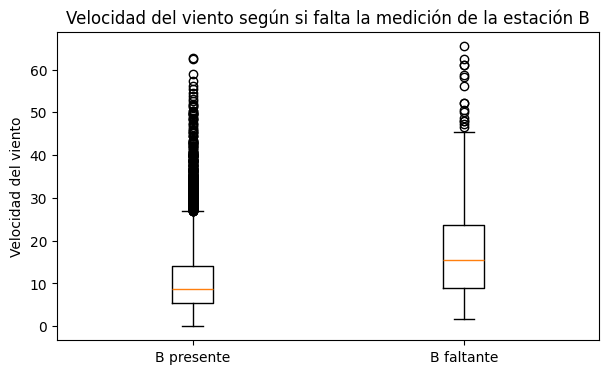

In [27]:
plt.figure(figsize=(7, 4))
plt.boxplot([df_air.loc[~falta_b, 'Wind_Speed'], df_air.loc[falta_b, 'Wind_Speed']])
plt.xticks([1, 2], ['B presente', 'B faltante'])
plt.title('Velocidad del viento según si falta la medición de la estación B')
plt.ylabel('Velocidad del viento')
plt.show()

**Tu observación:** _escribe aquí lo que observas._

### 4.3 Estación C: ¿cuándo faltan los datos?

In [28]:
horas_falta_c = df_air.loc[df_air['NO2_Location_C'].isna(), 'DateTime']

print('Horas del día con faltantes en C:')
print(horas_falta_c.dt.hour.value_counts().sort_index())
print()
print('Días de la semana con faltantes en C:')
print(horas_falta_c.dt.day_name().value_counts())
print()
print('Fechas con faltantes en C:')
print(horas_falta_c.dt.date.unique())

Horas del día con faltantes en C:
DateTime
10    12
11    12
12    12
13    12
14    12
15    12
16    12
17    12
18    12
19    12
20    12
Name: count, dtype: int64

Días de la semana con faltantes en C:
DateTime
Saturday    132
Name: count, dtype: int64

Fechas con faltantes en C:
[datetime.date(2020, 1, 25) datetime.date(2020, 2, 29)
 datetime.date(2020, 3, 28) datetime.date(2020, 4, 25)
 datetime.date(2020, 5, 30) datetime.date(2020, 6, 27)
 datetime.date(2020, 7, 25) datetime.date(2020, 8, 29)
 datetime.date(2020, 9, 26) datetime.date(2020, 10, 31)
 datetime.date(2020, 11, 28) datetime.date(2020, 12, 26)]


**Tu observación:** _escribe aquí lo que observas._

### 4.4 ¿Y MNAR?

MNAR no se puede demostrar solo con los datos: se sospecha por el conocimiento del proceso y se reporta como limitación.

**Completa la tabla con lo que encontraste:**

| Estación | % faltantes | Patrón | Mecanismo |
|---|---|---|---|
| A | | | |
| B | | | |
| C | | | |

---
## Bloque 5. Efecto en las medidas descriptivas

`skipna=True` (por omisión) ignora los faltantes.

**Predicción.** ¿Qué devolverá cada línea?

In [29]:
print('mean() por omisión:', df_air['NO2_Location_B'].mean())
print('mean(skipna=False):', df_air['NO2_Location_B'].mean(skipna=False))

mean() por omisión: 29.00056923451974
mean(skipna=False): nan


**Tu observación:** _escribe aquí lo que observas._

In [30]:
df_air[['NO2_Location_A', 'NO2_Location_B', 'NO2_Location_C']].describe().round(2)

,NO2_Location_A,NO2_Location_B,NO2_Location_C
count,8664.00,8204.00,8652.00
mean,22.05,29.00,45.35
std,15.60,20.63,26.74
min,-0.46,0.43,0.15
25%,10.60,13.90,24.03
50%,17.55,22.75,40.55
75%,29.30,38.61,62.12
max,116.60,151.85,168.28


### Cuando las columnas se combinan

Para comparar las tres estaciones hora por hora se necesitan filas completas.

**Predicción.** Si conservas solo las filas completas, ¿la velocidad media del viento subirá, bajará o se mantendrá?

In [31]:
completas = df_air.dropna()

print('Viento medio, todas las horas:     ', round(df_air['Wind_Speed'].mean(), 2))
print('Viento medio, solo horas completas:', round(completas['Wind_Speed'].mean(), 2))

Viento medio, todas las horas:      11.28
Viento medio, solo horas completas: 10.81


**Tu observación:** _escribe aquí lo que observas._

---
## Bloque 6. Tratamiento exploratorio

| Estrategia | Riesgo |
|---|---|
| Eliminar | Pierde información; sesga si es MAR |
| Marcar | Ninguno |
| Imputar | Reduce la variabilidad y deforma la distribución |

### 6.1 Eliminar: `dropna(subset=..., thresh=..., axis=...)`

**Predicción.** ¿Cuántas filas quedarán en cada caso?

In [32]:
print('Original:                         ', len(df_air))
print('dropna():                         ', len(df_air.dropna()))
print("dropna(subset=['NO2_Location_A']):", len(df_air.dropna(subset=['NO2_Location_A'])))
print('dropna(thresh=7):                 ', len(df_air.dropna(thresh=7)))
print("dropna(how='all'):                ", len(df_air.dropna(how='all')))
print('Columnas con dropna(axis=1):      ', list(df_air.dropna(axis=1).columns))

Original:                          8784
dropna():                          7970
dropna(subset=['NO2_Location_A']): 8664
dropna(thresh=7):                  8767
dropna(how='all'):                 8784
Columnas con dropna(axis=1):       ['DateTime', 'Temperature', 'Humidity', 'Wind_Speed', 'Wind_Direction']


**Tu observación:** _escribe aquí lo que observas._

### Práctica

Con **health_nutrition**:
1. Aplica `dropna(axis=0)` y `dropna(axis=1)` a `df_salud` y observa cuántas filas y columnas quedan. ¿Por qué `dropna()` sobre filas no es una opción aquí?
2. Aplica `dropna(axis=1, how='all')` para eliminar las columnas completamente vacías y guarda el resultado en otra variable.
3. Sobre ese resultado, conserva solo las columnas con al menos 50% de valores presentes usando `thresh` (pista: `thresh=int(len(df) * 0.5)`). Compara el tamaño final con el original.
4. Revisa qué columnas eliminaste en el paso 3. ¿Alguna tenía faltantes **no aplicables** (por ejemplo, `RIDEXPRG` o `RIDAGEMN`) en lugar de datos perdidos? ¿Cambia eso tu decisión de eliminarlas?

### 6.2 Marcar

In [33]:
df_air['B_faltante'] = df_air['NO2_Location_B'].isna().astype(int)
df_air['B_faltante'].value_counts()

,count
B_faltante,
0,8204
1,580


### 6.3 Imputación simple: `.fillna(valor)`

**Predicción.** Si rellenas los 580 faltantes de B con la media, ¿cambiará la media? ¿Y la desviación estándar?

In [34]:
b_original = df_air['NO2_Location_B']
b_media = b_original.fillna(b_original.mean())
b_mediana = b_original.fillna(b_original.median())

comparacion = pd.DataFrame({
    'original (sin faltantes)': [b_original.count(), b_original.mean(), b_original.median(), b_original.std()],
    'imputada con media': [b_media.count(), b_media.mean(), b_media.median(), b_media.std()],
    'imputada con mediana': [b_mediana.count(), b_mediana.mean(), b_mediana.median(), b_mediana.std()],
}, index=['n', 'media', 'mediana', 'desv. estándar']).round(2)
comparacion

,original (sin faltantes),imputada con media,imputada con mediana
n,8204.00,8784.00,8784.00
media,29.00,29.00,28.59
mediana,22.75,24.45,22.75
desv. estándar,20.63,19.94,20.00


**Tu observación:** _escribe aquí lo que observas._

Veamos la deformación en un histograma.

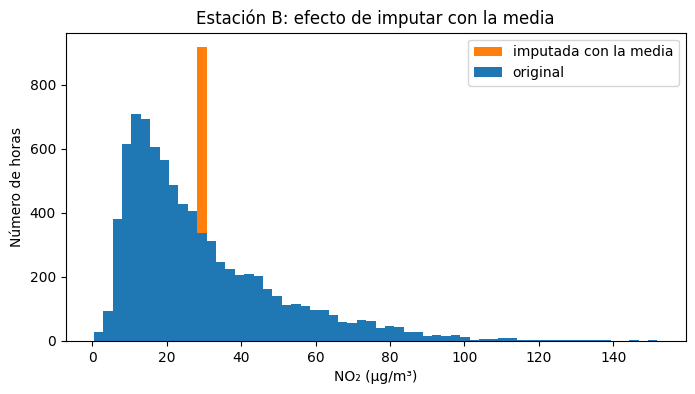

In [35]:
plt.figure(figsize=(8, 4))
plt.hist(b_media, bins=60, color='tab:orange', label='imputada con la media')
plt.hist(b_original, bins=60, color='tab:blue', label='original')
plt.title('Estación B: efecto de imputar con la media')
plt.xlabel('NO₂ (µg/m³)')
plt.ylabel('Número de horas')
plt.legend()
plt.show()

**Tu observación:** _escribe aquí lo que observas._

### Imputar varias columnas a la vez: `fillna({columna: valor})`

In [36]:
df_mediana = df_air.fillna({
    'NO2_Location_A': df_air['NO2_Location_A'].median(),
    'NO2_Location_B': df_air['NO2_Location_B'].median(),
    'NO2_Location_C': df_air['NO2_Location_C'].median(),
})

df_mediana[['NO2_Location_A', 'NO2_Location_B', 'NO2_Location_C']].count()

,0
NO2_Location_A,8784
NO2_Location_B,8784
NO2_Location_C,8784


### ¿Media o mediana?

| Imputación | Cuándo usarla | Ventaja | Desventaja |
|---|---|---|---|
| **Media** | Datos aproximadamente simétricos; faltantes MCAR | Sencilla; conserva la media | Sensible a atípicos; reduce la varianza; deforma la distribución |
| **Mediana** | Datos sesgados o con atípicos (como el NO₂) | Robusta a atípicos; conserva la mediana | Ignora las relaciones con otras variables; también reduce la varianza |

Ninguna de las dos usa información de las demás columnas. Las técnicas que sí lo hacen (por ejemplo, `KNNImputer`) se estudian en la Unidad 3.

### Práctica

1. Imputa `BMXWT` (peso) y `BMXBMI` (índice de masa corporal) de `df_salud` con la media y con la mediana. Compara con `describe()` la media, la mediana y la desviación estándar antes y después.
2. Grafica el histograma de `BMXBMI` antes y después de imputar con la media. ¿Aparece el pico artificial que viste en la estación B?
3. Antes de imputar `BMXBMI`, revisa quién no lo tiene: ¿qué edad tienen esas personas? (El índice de masa corporal no se calcula en menores de 2 años.)
4. ¿Tendría sentido imputar `DMDEDUC2` (nivel educativo) con la mediana? Justifica con lo que encontraste en la práctica de `missingno`.

### 6.4 Imputar un bloque en una serie de tiempo

**Predicción.** Si imputas con la media anual las 11 horas que faltan un sábado en C, ¿cómo se verá ese día?

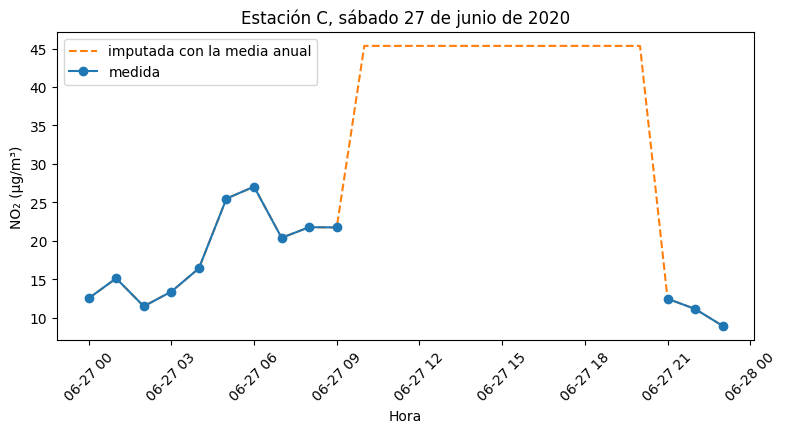

In [37]:
sabado = df_air[df_air['DateTime'].dt.date == pd.Timestamp('2020-06-27').date()]
c_imputada = sabado['NO2_Location_C'].fillna(df_air['NO2_Location_C'].mean())

plt.figure(figsize=(9, 4))
plt.plot(sabado['DateTime'], c_imputada, color='tab:orange', linestyle='--', label='imputada con la media anual')
plt.plot(sabado['DateTime'], sabado['NO2_Location_C'], color='tab:blue', marker='o', label='medida')
plt.title('Estación C, sábado 27 de junio de 2020')
plt.xlabel('Hora')
plt.ylabel('NO₂ (µg/m³)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

**Tu observación:** _escribe aquí lo que observas._

### Propagación: `ffill()` (último valor anterior) y `bfill()` (siguiente valor)

**Predicción.** ¿Qué valor pondrá cada uno en las 11 horas faltantes del sábado?

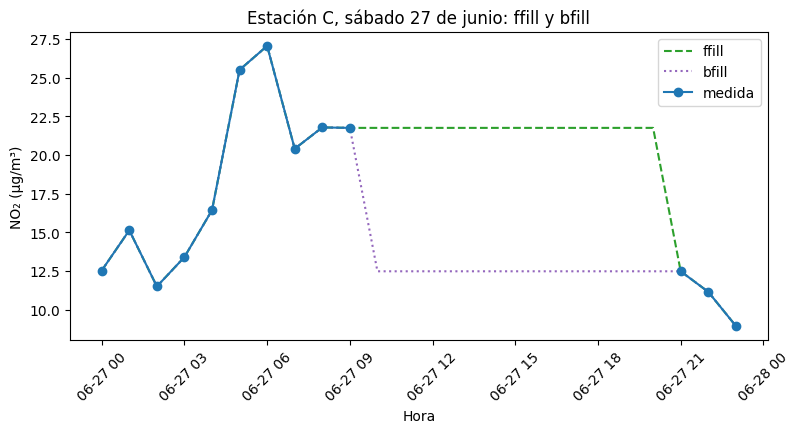

In [38]:
c_ffill = df_air['NO2_Location_C'].ffill()
c_bfill = df_air['NO2_Location_C'].bfill()

plt.figure(figsize=(9, 4))
plt.plot(sabado['DateTime'], c_ffill[sabado.index], color='tab:green', linestyle='--', label='ffill')
plt.plot(sabado['DateTime'], c_bfill[sabado.index], color='tab:purple', linestyle=':', label='bfill')
plt.plot(sabado['DateTime'], sabado['NO2_Location_C'], color='tab:blue', marker='o', label='medida')
plt.title('Estación C, sábado 27 de junio: ffill y bfill')
plt.xlabel('Hora')
plt.ylabel('NO₂ (µg/m³)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

**Tu observación:** _escribe aquí lo que observas._

---
## Bloque 7. Cuando el faltante tiene significado

**Predicción.** ¿Por qué un anuncio de Airbnb no tendría reseñas por mes?

In [39]:
sin_resenas = df_bnb['number_of_reviews'] == 0
falta_rpm = df_bnb['reviews_per_month'].isna()

print('Anuncios con 0 reseñas:                 ', sin_resenas.sum())
print('Anuncios sin reviews_per_month:         ', falta_rpm.sum())
print('¿Coinciden exactamente las dos máscaras?', (sin_resenas == falta_rpm).all())

Anuncios con 0 reseñas:                  10052
Anuncios sin reviews_per_month:          10052
¿Coinciden exactamente las dos máscaras? True


**Tu observación:** _escribe aquí lo que observas._

**Predicción.** ¿Qué pasaría si se imputara con la media?

In [40]:
rpm_media = df_bnb['reviews_per_month'].fillna(df_bnb['reviews_per_month'].mean())
rpm_cero = df_bnb['reviews_per_month'].fillna(0)

print('Media original (solo con reseñas):', round(df_bnb['reviews_per_month'].mean(), 3))
print('Media imputando con la media:     ', round(rpm_media.mean(), 3))
print('Media imputando con 0:            ', round(rpm_cero.mean(), 3))

Media original (solo con reseñas): 1.373
Media imputando con la media:      1.373
Media imputando con 0:             1.091


**Tu observación:** _escribe aquí lo que observas._

### Imputación con la moda: `serie.mode()[0]`

**Predicción.** `host_name` tiene 21 faltantes. ¿Qué valor asignaría la moda?

In [41]:
moda_host = df_bnb['host_name'].mode()[0]
print('Moda de host_name:', moda_host)
print('Anuncios con ese nombre:', (df_bnb['host_name'] == moda_host).sum())

Moda de host_name: Michael
Anuncios con ese nombre: 417


**Tu observación:** _escribe aquí lo que observas._

In [42]:
df_cat = pd.DataFrame({
    'ID': [1, 2, 3, 4, 5, 6],
    'Ciudad': ['Madrid', np.nan, 'Barcelona', 'Madrid', np.nan, 'Madrid']
})
df_cat['Ciudad'] = df_cat['Ciudad'].astype('category')

moda_ciudad = df_cat['Ciudad'].mode()[0]
print('Moda:', moda_ciudad)
df_cat['Ciudad'] = df_cat['Ciudad'].fillna(moda_ciudad)
df_cat

Moda: Madrid


,ID,Ciudad
0,1,Madrid
1,2,Madrid
2,3,Barcelona
3,4,Madrid
4,5,Madrid
5,6,Madrid


In [43]:
host_imputado = df_bnb['host_name'].fillna('Sin nombre')
(host_imputado == 'Sin nombre').sum()

np.int64(21)

---
## Bloque 8. Cierre

**Ruta de decisión:** cuantifica → visualiza → pregunta por qué faltan → decide según la pregunta y el mecanismo → reporta cuántos datos usaste.

**Para cada situación, anota el tratamiento que elegirías:**

| Situación | Tratamiento |
|---|---|
| Pocos faltantes, MCAR | |
| MAR | |
| Patrón sistemático | |
| El dato no aplica y su valor se conoce | |
| Sospecha de MNAR | |